In [2]:
from pathlib import Path
from dataclasses import dataclass
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


from process_ccf import process_ccf_dataset
from process_ccf import concat_ccf_csv_files



2026-05-08 10:08:37.795075: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-08 10:08:37.877235: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778231317.910781  169587 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778231317.920335  169587 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778231317.991703  169587 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
full_df = pd.read_parquet("./CCFs/random_rv_iccf_datasets_snr_merged_normalized.parquet")
full_df
                          

,rv_true_mps,rv_iccf_mps,fwhm_kms,bis_mps,vspan_mps,wspan_mps,contrast_percent,ccf_0000,ccf_0001,ccf_0002,...,ccf_0299,ccf_0300,snr,activity,fixed_seed,fixed_seed_id,source_folder,source_file,ccf_descriptor,dataset_label
0,82.01,-144.097125,6.599835,-35.005783,-26.788041,-606.359591,56.696423,0.9782,0.9781,0.9783,...,0.9882,0.9879,20p0,plage,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_plage_lonm0p391728_latp11p1...,plage|snr=20p0|random_seed|random_rv_iccf_ar1_...,active_snr_20p0
1,29.20,-196.915108,6.600317,-35.108102,-25.532521,-607.916255,56.697067,0.9781,0.9782,0.9784,...,0.9881,0.9876,20p0,plage,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_plage_lonm0p391728_latp11p1...,plage|snr=20p0|random_seed|random_rv_iccf_ar1_...,active_snr_20p0
2,75.02,-151.093671,6.599898,-35.037001,-26.639270,-606.509978,56.696505,0.9782,0.9781,0.9783,...,0.9882,0.9878,20p0,plage,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_plage_lonm0p391728_latp11p1...,plage|snr=20p0|random_seed|random_rv_iccf_ar1_...,active_snr_20p0
3,2.57,-223.542203,6.600578,-34.946434,-27.274065,-604.621989,56.697316,0.9781,0.9782,0.9785,...,0.9880,0.9875,20p0,plage,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_plage_lonm0p391728_latp11p1...,plage|snr=20p0|random_seed|random_rv_iccf_ar1_...,active_snr_20p0
4,49.21,-176.906858,6.600132,-35.139980,-26.118377,-607.225668,56.696813,0.9782,0.9781,0.9783,...,0.9882,0.9877,20p0,plage,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_plage_lonm0p391728_latp11p1...,plage|snr=20p0|random_seed|random_rv_iccf_ar1_...,active_snr_20p0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015195,98.75,-125.479807,6.597406,-35.081919,-28.666788,-602.829436,56.711306,0.9788,0.9788,0.9788,...,0.9881,0.9881,800p0,spot,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_spot_lonp9p99644_latm46p255...,spot|snr=800p0|random_seed|random_rv_iccf_ar1_...,active_snr_800p0
2015196,91.67,-132.557164,6.597474,-35.106180,-28.471795,-602.866726,56.711361,0.9788,0.9788,0.9788,...,0.9881,0.9881,800p0,spot,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_spot_lonp9p99644_latm46p255...,spot|snr=800p0|random_seed|random_rv_iccf_ar1_...,active_snr_800p0
2015197,72.85,-151.381449,6.597646,-35.184436,-27.978022,-602.998998,56.711557,0.9788,0.9788,0.9788,...,0.9881,0.9881,800p0,spot,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_spot_lonp9p99644_latm46p255...,spot|snr=800p0|random_seed|random_rv_iccf_ar1_...,active_snr_800p0
2015198,14.19,-210.036410,6.598196,-35.057732,-29.117631,-601.425394,56.712236,0.9788,0.9788,0.9787,...,0.9881,0.9881,800p0,spot,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_spot_lonp9p99644_latm46p255...,spot|snr=800p0|random_seed|random_rv_iccf_ar1_...,active_snr_800p0


In [10]:
residual = full_df['rv_true_mps'] - full_df['rv_iccf_mps'] - 2.241024e+02

q10 = residual.quantile(0.005)
q90 = residual.quantile(0.995)

bottom_10 = full_df[residual <= q10].copy()
top_10 = full_df[residual >= q90].copy()

sample_df = pd.concat([bottom_10, top_10], ignore_index=True)


In [12]:
sample_df.to_csv('soap_simulated_data.csv', index=False)

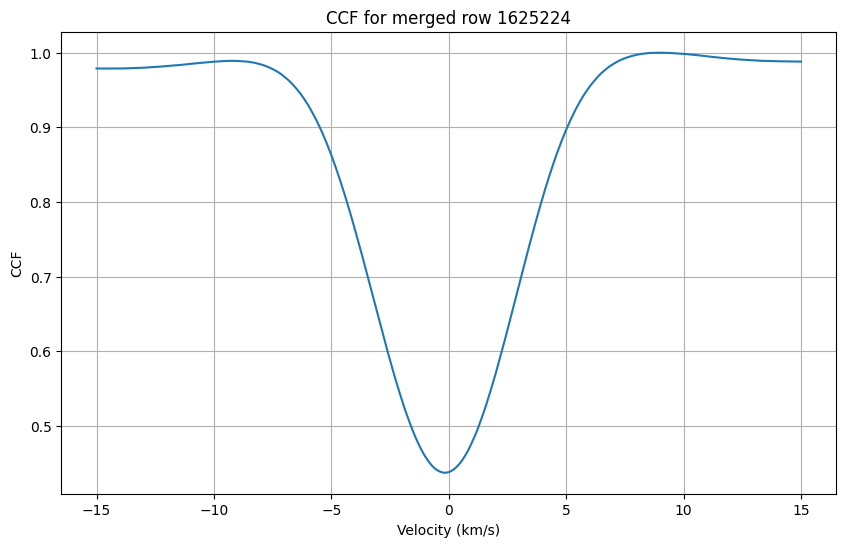

In [15]:
# Plot CCF for a given row
row_index = 1625224  # Change this to the desired row index
velocities = np.arange(-15, 15.1, 0.1)
ccf_columns = [f'ccf_{i:04d}' for i in range(301)]
ccf_values = sample_df.loc[row_index, ccf_columns].values

plt.figure(figsize=(10, 6))
plt.plot(velocities, ccf_values)
plt.xlabel('Velocity (km/s)')
plt.ylabel('CCF')
plt.title(f'CCF for merged row {row_index}')
plt.grid(True)
plt.show()

In [29]:
sample_df

,rv_true_mps,rv_iccf_mps,fwhm_kms,bis_mps,vspan_mps,wspan_mps,contrast_percent,ccf_0000,ccf_0001,ccf_0002,...,ccf_0299,ccf_0300,snr,activity,fixed_seed,fixed_seed_id,source_folder,source_file,ccf_descriptor,dataset_label
1625224,31.81,-191.566204,6.598694,-35.467354,-27.047241,-602.983875,56.709643,0.9789,0.9788,0.9788,...,0.9882,0.9881,400p0,spot,True,2.0,random_fixed_seed2_rv_iccf_datasets_snr,random_rv_iccf_ar1_spot_lonm11p9852_latp17p367...,spot|snr=400p0|fixed_seed2|random_rv_iccf_ar1_...,active_snr_400p0
771498,93.49,-130.984962,6.596152,-35.505867,-29.314550,-600.413264,56.717424,0.9787,0.9786,0.9785,...,0.9882,0.9882,80p0,plage,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_plage_lonm64p8428_latm64p42...,plage|snr=80p0|random_seed|random_rv_iccf_ar1_...,active_snr_80p0
645588,65.21,-159.709562,6.595101,-34.629393,-26.750593,-601.534445,56.711845,0.9782,0.9782,0.9783,...,0.9874,0.9873,50p0,spot,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_spot_lonp88p8822_latp81p037...,spot|snr=50p0|random_seed|random_rv_iccf_ar1_s...,active_snr_50p0
469452,43.06,-181.163796,6.599376,-37.039711,-27.522106,-603.505727,56.710061,0.9783,0.9783,0.9782,...,0.9879,0.9878,50p0,spot,True,3.0,random_fixed_seed3_rv_iccf_datasets_snr,random_rv_iccf_ar1_spot_lonm21p0689_latm20p682...,spot|snr=50p0|fixed_seed3|random_rv_iccf_ar1_s...,active_snr_50p0
679316,60.77,-163.469131,6.595711,-36.317759,-28.981045,-612.325935,56.719378,0.9787,0.9786,0.9785,...,0.9881,0.9882,60p0,spot,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_spot_lonm33p494_latm13p6479...,spot|snr=60p0|random_seed|random_rv_iccf_ar1_s...,active_snr_60p0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1866480,51.18,-172.693498,6.597722,-35.370592,-27.627792,-603.851454,56.714115,0.9787,0.9787,0.9786,...,0.9881,0.9880,500p0,plage,True,1.0,random_fixed_seed1_rv_iccf_datasets_snr,random_rv_iccf_ar1_plage_lonp36p5886_latm41p11...,plage|snr=500p0|fixed_seed1|random_rv_iccf_ar1...,active_snr_500p0
160577,40.31,-186.056362,6.598480,-31.214955,-21.460703,-599.669541,56.728684,0.9781,0.9781,0.9781,...,0.9866,0.9866,30p0,spot,True,1.0,random_fixed_seed1_rv_iccf_datasets_snr,random_rv_iccf_ar1_spot_lonp69p7246_latp15p159...,spot|snr=30p0|fixed_seed1|random_rv_iccf_ar1_s...,active_snr_30p0
16960,86.93,-139.389433,6.590542,-33.717723,-26.503252,-582.397691,56.737416,0.9803,0.9800,0.9796,...,0.9882,0.9885,20p0,plage,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_plage_lonp28p1113_latm41p22...,plage|snr=20p0|random_seed|random_rv_iccf_ar1_...,active_snr_20p0
652285,4.53,-218.856762,6.597086,-36.649259,-29.482263,-594.689754,56.708670,0.9790,0.9790,0.9791,...,0.9882,0.9881,60p0,plage,False,NaN,random_rv_iccf_datasets_snr,random_rv_iccf_ar1_plage_lonm45p384_latp53p671...,plage|snr=60p0|random_seed|random_rv_iccf_ar1_...,active_snr_60p0


In [17]:
ccf_cols = [f'ccf_{i:04d}' for i in range(301)]#[c for c in full_df.columns if c.startswith("ccf_")]

X = sample_df[ccf_cols].to_numpy(dtype=np.float32)
y = pd.to_numeric(sample_df["rv_true_mps"], errors="coerce").to_numpy(dtype=np.float32).reshape(-1, 1)

In [18]:
# Split merged quiet+active dataset into train/dev/test: 70% / 15% / 15%
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, shuffle=True
)

X_dev, X_test, y_dev, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, shuffle=True
)

print("Train:", X_train.shape, y_train.shape)
print("Dev:  ", X_dev.shape, y_dev.shape)
print("Test: ", X_test.shape, y_test.shape)


Train: (7000, 301) (7000, 1)
Dev:   (1500, 301) (1500, 1)
Test:  (1500, 301) (1500, 1)


In [19]:
# Scale features and target for stable training
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_s = x_scaler.fit_transform(X_train)
X_dev_s = x_scaler.transform(X_dev)
X_test_s = x_scaler.transform(X_test)

y_train_s = y_scaler.fit_transform(y_train)
y_dev_s = y_scaler.transform(y_dev)
y_test_s = y_scaler.transform(y_test)


In [26]:
# Simple MLP baseline
model = keras.Sequential([
    layers.Input(shape=(X_train_s.shape[1],)),
    layers.Dense(64, activation="relu"),
    #layers.Dropout(0.20),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
)

callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.7,
        patience=10,
        min_lr=1e-5,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )
]


history = model.fit(
    X_train_s,
    y_train_s,
    validation_data=(X_dev_s, y_dev_s),
    epochs=200,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3505 - mae: 0.3664 - val_loss: 0.0474 - val_mae: 0.1409 - learning_rate: 1.0000e-04
Epoch 2/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0428 - mae: 0.1301 - val_loss: 0.0276 - val_mae: 0.1062 - learning_rate: 1.0000e-04
Epoch 3/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0248 - mae: 0.0999 - val_loss: 0.0203 - val_mae: 0.0909 - learning_rate: 1.0000e-04
Epoch 4/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0175 - mae: 0.0849 - val_loss: 0.0164 - val_mae: 0.0820 - learning_rate: 1.0000e-04
Epoch 5/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0134 - mae: 0.0754 - val_loss: 0.0139 - val_mae: 0.0754 - learning_rate: 1.0000e-04
Epoch 6/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0108 - mae: 0.0683 - val_loss: 0.0121 - val_mae: 0.0703 - learning_rate: 1.0000e-04
Epoch 7/200
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0088 - mae: 0.0627 - val_loss: 0.0108 - val_mae: 0.0661

In [27]:
def evaluate_regression(model, X_s, y_true, scaler, split_name):
    y_pred_s = model.predict(X_s, verbose=0)
    y_pred = scaler.inverse_transform(y_pred_s).ravel()
    y_true = y_true.ravel()

    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)

    print(f"{split_name} -> MAE: {mae:.6f}, RMSE: {rmse:.6f}, R2: {r2:.6f}")
    return y_pred

y_dev_pred = evaluate_regression(model, X_dev_s, y_dev, y_scaler, "Dev")
y_test_pred = evaluate_regression(model, X_test_s, y_test, y_scaler, "Test")


Dev -> MAE: 0.468458, RMSE: 0.921046, R2: 0.998971
Test -> MAE: 0.462997, RMSE: 0.826293, R2: 0.999212


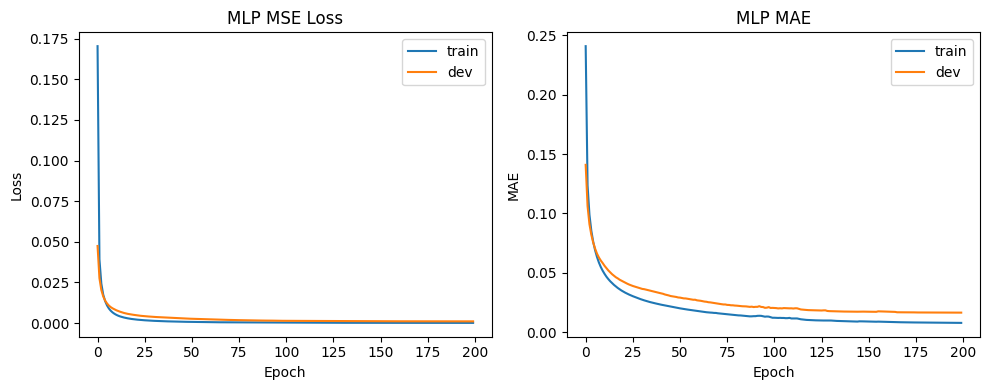

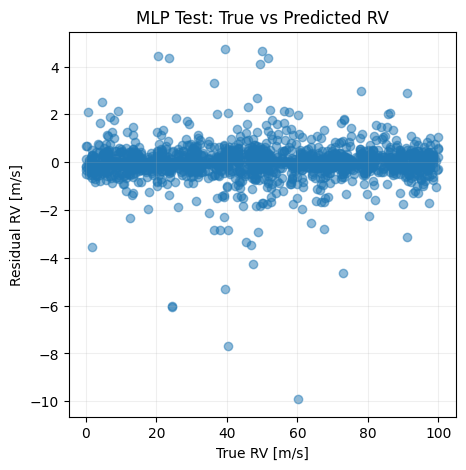

In [28]:
# MLP training curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="dev")
plt.title("MLP MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="train")
plt.plot(history.history["val_mae"], label="dev")
plt.title("MLP MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()

# MLP prediction scatter on test split
plt.figure(figsize=(5, 5))
plt.scatter(y_test.ravel(), y_test.ravel() - y_test_pred, alpha=0.5)
min_v = min(y_test.min(), y_test_pred.min())
max_v = max(y_test.max(), y_test_pred.max())
#plt.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=1)
plt.xlabel("True RV [m/s]")
plt.ylabel("Residual RV [m/s]")
plt.title("MLP Test: True vs Predicted RV")
plt.grid(True, alpha=0.2)
plt.show()
